170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training SVM with RBF kernel, C=10, gamma=scale)...
Evaluating model...
Accuracy: 0.64
Global Accuracy: 0.64


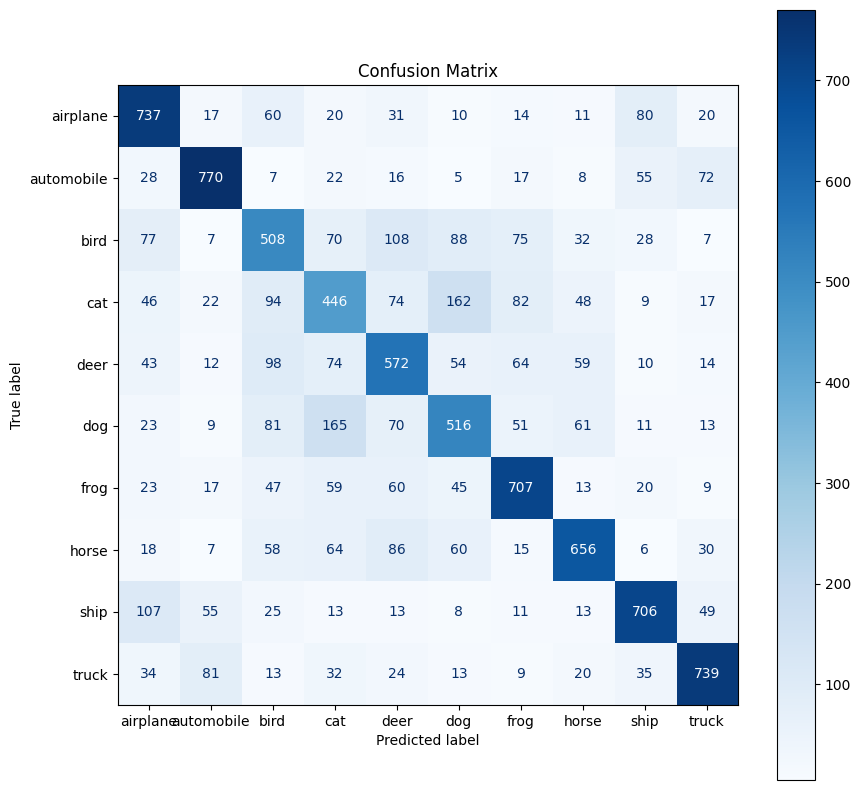


--- Per-Class Accuracy ---
airplane    : 73.70%
automobile  : 77.00%
bird        : 50.80%
cat         : 44.60%
deer        : 57.20%
dog         : 51.60%
frog        : 70.70%
horse       : 65.60%
ship        : 70.60%
truck       : 73.90%


In [ ]:
import numpy as np
import tensorflow as tf
import time
from skimage.feature import hog
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix


# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Flatten labels
y_train = y_train.flatten()
y_test = y_test.flatten()

# HOG Feature Extraction
def extract_hog_features(images):
    hog_features = []
    for image in images:
        gray_image = np.dot(image[..., :3], [0.299, 0.587, 0.114])
        hog_feature = hog(gray_image, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=False)
        hog_features.append(hog_feature)
    return np.array(hog_features)

x_train = extract_hog_features(x_train)
x_test = extract_hog_features(x_test)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

pca = PCA(n_components=0.95)  # Retain 95% variance
X_train = pca.fit_transform(x_train)
X_test = pca.transform(x_test)
C_value = 10
gamma_value = 'scale'
print(f"Training SVM with RBF kernel, C={C_value}, gamma={gamma_value})...")

start_time = time.time()
svm_rbf3 = SVC(kernel='rbf', C=C_value, gamma=gamma_value, decision_function_shape='ovr')
svm_rbf3.fit(x_train, y_train)
print("Evaluating model...")
y_pred = svm_rbf3.predict(x_test)
end_time = time.time()

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Global Accuracy: {accuracy:.2f}")


# 2. Calculate Per-Class Accuracy
# Divide diagonal elements (correct preds) by the row sums (total true samples per class)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\n Per-Class Accuracy ")
for i, acc in enumerate(per_class_accuracy):
    print(f"{class_names[i]:<12}: {acc*100:.2f}%")

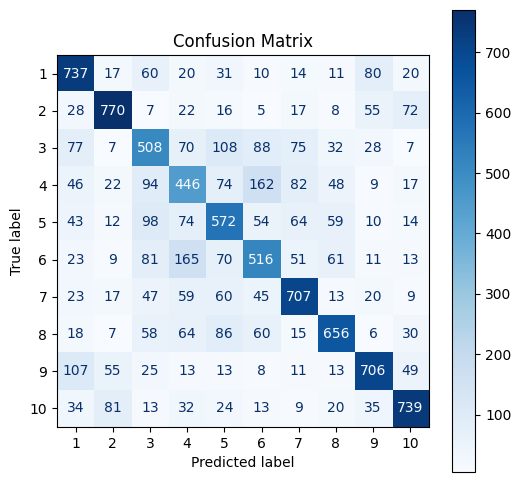

In [ ]:
class_names = [1, 2,3,4,5,6,7,8,9,10]

# 1. Compute and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Increase figure size for better visibility
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d') # 'd' formats numbers as integers
plt.title(f"Confusion Matrix")
plt.show()

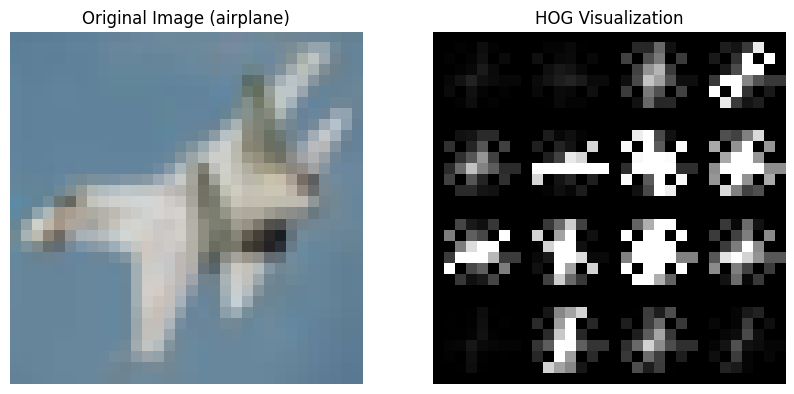

In [ ]:
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
import tensorflow as tf
import numpy as np

# image reloading
(_, _), (x_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

#random selection
idx = 10
image = x_test_raw[idx]
label = y_test_raw[idx][0]
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# convert to grayscale (HOG works on 1 channel)
gray_image = np.dot(image[..., :3], [0.299, 0.587, 0.114])

#  HOG with visualize=True
#
fd, hog_image = hog(gray_image,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    visualize=True)


hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# plot side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image)
ax1.set_title(f'Original Image ({class_names[label]})')

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('HOG Visualization')

plt.show()

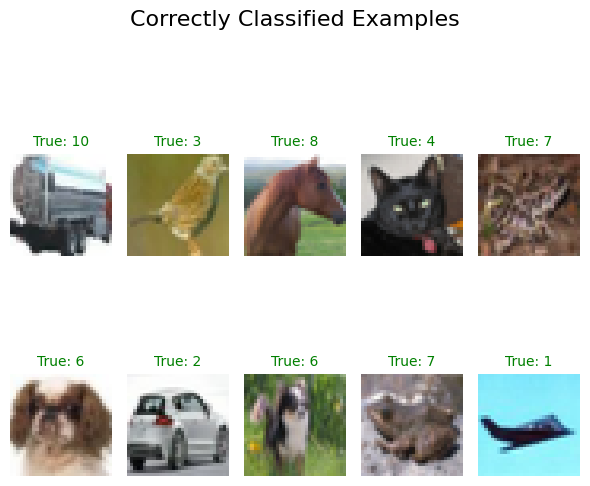

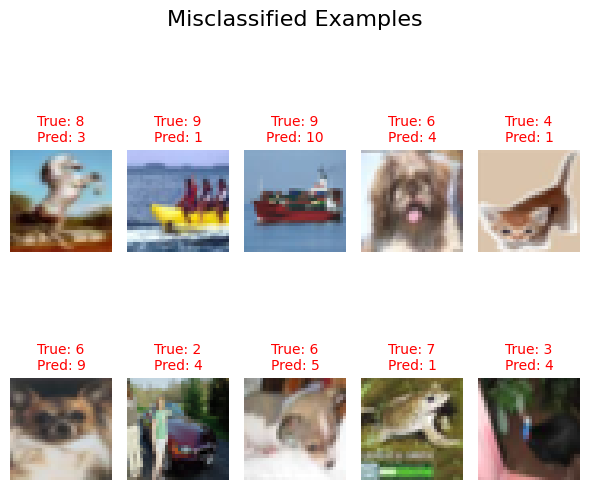

In [ ]:
# reload raw images for visualization (since x_test currently holds HOG features)
(_, _), (x_test_raw, _) = tf.keras.datasets.cifar10.load_data()

# indices of correct and incorrect predictions
correct_indices = np.where(y_pred == y_test)[0]
incorrect_indices = np.where(y_pred != y_test)[0]

def plot_images(indices, title_text, num_rows=2, num_cols=5):
    plt.figure(figsize=(6, 6))
    plt.suptitle(title_text, fontsize=16)


    selected_indices = np.random.choice(indices, num_rows * num_cols, replace=False)

    for i, idx in enumerate(selected_indices):
        plt.subplot(num_rows, num_cols, i + 1)
        plt.imshow(x_test_raw[idx])

        true_label = class_names[y_test[idx]]
        pred_label = class_names[y_pred[idx]]

        if true_label == pred_label:
            color = 'green'
            label_text = f"True: {true_label}"
        else:
            color = 'red'
            label_text = f"True: {true_label}\nPred: {pred_label}"

        plt.title(label_text, color=color, fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


if len(correct_indices) > 0:
    plot_images(correct_indices, "Correctly Classified Examples")


if len(incorrect_indices) > 0:
    plot_images(incorrect_indices, "Misclassified Examples")